In [1]:
#Khởi chạy các thư viện
#pip install ta vnstock yfinance lightgbm xgboost

In [2]:
#thư viện
import pandas as pd
from vnstock import *
import yfinance as yf

In [3]:
#tắt cảnh báo
import warnings
warnings.filterwarnings('ignore')

In [4]:
#Thiết lập các dữ liệu trong dataframe chỉ hiện 3 số sau dấu phẩy
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Lấy dữ liệu vnstock

In [5]:
quote = Quote(symbol='VNINDEX', source='VCI') #Dùng source = KBS nếu không chạy được

In [6]:
#Chỉ số VNIndex
VNIndex_historical_data=quote.history(start='2015-06-16', end='2025-04-01', interval='1D')
# Đặt cột 'time' làm cột index
VNIndex_historical_data.set_index('time', inplace=True)
VNIndex_historical_data

,open,high,low,close,volume
time,,,,,
2015-01-05,544.860,549.220,543.780,544.450,91834620
2015-01-06,539.080,550.110,538.820,549.660,94081890
2015-01-07,548.440,555.830,548.440,552.050,109445780
2015-01-08,553.490,556.800,552.150,553.470,73883040
2015-01-09,553.490,570.520,552.150,569.730,104203680
...,...,...,...,...,...
2025-03-26,1333.330,1338.550,1323.690,1326.090,672071249
2025-03-27,1325.980,1328.820,1323.010,1323.810,522142993
2025-03-28,1324.420,1325.340,1315.720,1317.460,601970197


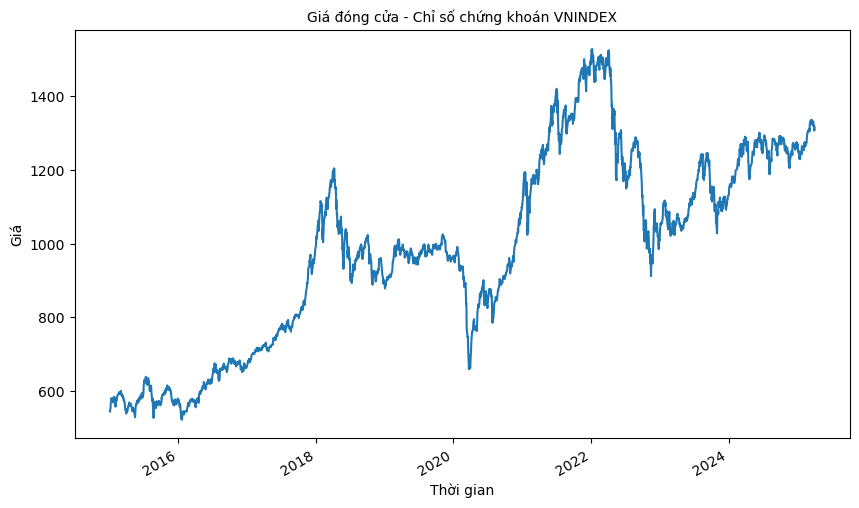

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Giá đóng cửa - Chỉ số chứng khoán VNINDEX'}, xlabel='Thời gian', ylabel='Giá'>)

In [7]:
VNIndex_historical_data['close'].viz.timeseries(figsize=(10, 6), 
                           title='Giá đóng cửa - Chỉ số chứng khoán VNINDEX', 
                           ylabel='Giá', 
                           xlabel='Thời gian',
                           color_palette='vnstock',
                           palette_shuffle=True)

# Dữ liệu vĩ mô

### Tỷ giá USD/VND

In [8]:
#Tỷ giá (đơn vị VND)
# Lấy dữ liệu USD/VND (Yahoo Finance có mã là 'VND=X')
usd_vnd = yf.download("VND=X", start="2015-01-01", end="2025-04-02", interval="1d")
usd_vnd.columns = usd_vnd.columns.set_levels(
    ['USD/VND' if level == 'VND=X' else level for level in usd_vnd.columns.levels[1]],
    level='Ticker')

usd_vnd

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,USD/VND,USD/VND,USD/VND,USD/VND,USD/VND
Date,,,,,
2015-01-01,21375.000,21375.000,21156.000,21157.000,0
2015-01-02,21063.000,21214.000,21063.000,21214.000,0
2015-01-05,21046.000,21375.000,21046.000,21219.000,0
2015-01-06,21097.000,21390.000,20987.000,20987.000,0
2015-01-07,21083.000,21415.000,21083.000,21135.000,0
...,...,...,...,...,...
2025-03-26,25600.000,25630.000,25550.000,25600.000,0
2025-03-27,25555.000,25610.000,25550.000,25555.000,0


### Giá vàng

In [9]:
#Giá vàng (đơn vị USD)
gold = yf.download("GC=F", start="2015-01-01", end="2025-04-02", interval="1d")
gold.columns = gold.columns.set_levels(
    ['Gold' if level == 'GC=F' else level for level in gold.columns.levels[1]],
    level='Ticker')
gold

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,Gold,Gold,Gold,Gold,Gold
Date,,,,,
2015-01-02,1186.000,1194.500,1169.500,1184.000,138
2015-01-05,1203.900,1206.900,1180.100,1180.300,470
2015-01-06,1219.300,1220.000,1203.500,1203.500,97
2015-01-07,1210.600,1219.200,1210.600,1219.200,29
2015-01-08,1208.400,1215.700,1206.300,1207.000,92
...,...,...,...,...,...
2025-03-26,3020.900,3033.200,3019.500,3033.200,83
2025-03-27,3060.200,3065.000,3025.500,3025.500,124359


### Giá dầu

In [10]:
#Giá dầu (đơn vị USD)
symbol = "CL=F"  # WTI

# Lấy dữ liệu từ 2020-01-01 đến 2025-04-01
petro_price = yf.download(symbol, start="2015-01-01", end="2025-04-02")

petro_price.columns = petro_price.columns.set_levels(
    ['Oil' if level == 'CL=F' else level for level in petro_price.columns.levels[1]],
    level='Ticker')

# Hiển thị dữ liệu
petro_price

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,Oil,Oil,Oil,Oil,Oil
Date,,,,,
2015-01-02,52.690,55.110,52.030,53.760,268708
2015-01-05,50.040,52.730,49.680,52.610,375782
2015-01-06,47.930,50.370,47.550,50.000,451642
2015-01-07,48.650,49.310,46.830,48.000,460083
2015-01-08,48.790,49.650,47.730,48.780,362081
...,...,...,...,...,...
2025-03-26,69.650,70.220,69.060,69.160,262413
2025-03-27,69.920,69.970,69.120,69.960,211825


### S&P 500

In [11]:
# Ticker S&P 500
sp500 = yf.download('^GSPC', start="2015-01-01",  end="2025-04-02", interval='1d', progress=True)

sp500.columns = sp500.columns.set_levels(
    ['S&P500' if level == '^GSPC' else level for level in sp500.columns.levels[1]], level='Ticker')

# Hiển thị
sp500

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,S&P500,S&P500,S&P500,S&P500,S&P500
Date,,,,,
2015-01-02,2058.200,2072.360,2046.040,2058.900,2708700000
2015-01-05,2020.580,2054.440,2017.340,2054.440,3799120000
2015-01-06,2002.610,2030.250,1992.440,2022.150,4460110000
2015-01-07,2025.900,2029.610,2005.550,2005.550,3805480000
2015-01-08,2062.140,2064.080,2030.610,2030.610,3934010000
...,...,...,...,...,...
2025-03-26,5712.200,5783.620,5694.410,5771.660,4183140000
2025-03-27,5693.310,5732.280,5670.940,5695.640,4403460000


# Gộp dữ liệu thô

In [12]:
raw=pd.concat([VNIndex_historical_data, usd_vnd, gold, petro_price, sp500], axis=1, sort=True)
raw

,open,high,low,close,volume,"(Close, USD/VND)","(High, USD/VND)","(Low, USD/VND)","(Open, USD/VND)","(Volume, USD/VND)",...,"(Close, Oil)","(High, Oil)","(Low, Oil)","(Open, Oil)","(Volume, Oil)","(Close, S&P500)","(High, S&P500)","(Low, S&P500)","(Open, S&P500)","(Volume, S&P500)"
2015-01-01,NaN,NaN,NaN,NaN,NaN,21375.000,21375.000,21156.000,21157.000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-02,NaN,NaN,NaN,NaN,NaN,21063.000,21214.000,21063.000,21214.000,0.000,...,52.690,55.110,52.030,53.760,268708.000,2058.200,2072.360,2046.040,2058.900,2708700000.000
2015-01-05,544.860,549.220,543.780,544.450,91834620.000,21046.000,21375.000,21046.000,21219.000,0.000,...,50.040,52.730,49.680,52.610,375782.000,2020.580,2054.440,2017.340,2054.440,3799120000.000
2015-01-06,539.080,550.110,538.820,549.660,94081890.000,21097.000,21390.000,20987.000,20987.000,0.000,...,47.930,50.370,47.550,50.000,451642.000,2002.610,2030.250,1992.440,2022.150,4460110000.000
2015-01-07,548.440,555.830,548.440,552.050,109445780.000,21083.000,21415.000,21083.000,21135.000,0.000,...,48.650,49.310,46.830,48.000,460083.000,2025.900,2029.610,2005.550,2005.550,3805480000.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-26,1333.330,1338.550,1323.690,1326.090,672071249.000,25600.000,25630.000,25550.000,25600.000,0.000,...,69.650,70.220,69.060,69.160,262413.000,5712.200,5783.620,5694.410,5771.660,4183140000.000
2025-03-27,1325.980,1328.820,1323.010,1323.810,522142993.000,25555.000,25610.000,25550.000,25555.000,0.000,...,69.920,69.970,69.120,69.960,211825.000,5693.310,5732.280,5670.940,5695.640,4403460000.000
2025-03-28,1324.420,1325.340,1315.720,1317.460,601970197.000,25560.000,25580.000,25540.000,25560.000,0.000,...,69.360,70.090,68.870,69.910,246650.000,5580.940,5685.890,5572.420,5679.200,4513330000.000
2025-03-31,1313.510,1314.090,1304.100,1306.860,706353460.000,25550.000,25575.000,25530.000,25550.000,0.000,...,71.480,71.830,68.810,69.430,313087.000,5611.850,5627.560,5488.730,5527.910,5257250000.000


In [13]:
# Đổi tên cột
raw_data = raw.rename(columns={
    ('Close', 'USD/VND'): 'USD/VND',
    ('Close', 'Gold'): 'Gold',
    ('Close', 'S&P500'): 'SP500',
    ('Close', 'Oil'): 'Oil'
})

# Xóa cột
raw_data = raw_data.drop(columns=[
    ('High', 'USD/VND'), ('Low', 'USD/VND'), ('Open', 'USD/VND'), ('Volume', 'USD/VND'),
    ('High', 'Gold'), ('Low', 'Gold'), ('Open', 'Gold'), ('Volume', 'Gold'),
    ('High', 'Oil'), ('Low', 'Oil'), ('Open', 'Oil'), ('Volume', 'Oil'),
    ('High', 'S&P500'), ('Low', 'S&P500'), ('Open', 'S&P500'), ('Volume', 'S&P500')
])

In [14]:
raw_data.head()

,open,high,low,close,volume,USD/VND,Gold,Oil,SP500
2015-01-01,NaN,NaN,NaN,NaN,NaN,21375.000,NaN,NaN,NaN
2015-01-02,NaN,NaN,NaN,NaN,NaN,21063.000,1186.000,52.690,2058.200
2015-01-05,544.860,549.220,543.780,544.450,91834620.000,21046.000,1203.900,50.040,2020.580
2015-01-06,539.080,550.110,538.820,549.660,94081890.000,21097.000,1219.300,47.930,2002.610
2015-01-07,548.440,555.830,548.440,552.050,109445780.000,21083.000,1210.600,48.650,2025.900


In [15]:
with pd.ExcelWriter("VNINDEX-Forecasting-Data.xlsx", engine="openpyxl") as writer:
    raw_data.to_excel(writer, sheet_name="Dữ liệu thô", index=True)